<a href="https://colab.research.google.com/github/mutallimov7/CERN-Open-Data-Analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q uproot awkward vector

In [2]:
import uproot
import awkward as ak
import vector
import numpy as np
import matplotlib.pyplot as plt

vector.register_awkward()
print("uproot:", uproot.__version__)

uproot: 5.7.6


In [3]:
# Download the file with cross-sections, sums of weights and dataset IDs
!wget -q https://raw.githubusercontent.com/atlas-outreach-data-tools/notebooks-collection-opendata/master/13-TeV-examples/uproot_python/infofile.py
import infofile
print(infofile.infos["ggH125_ZZ4lep"])

{'DSID': 345060, 'events': 985000, 'red_eff': 1, 'sumw': 27881776.6536, 'xsec': 0.0060239}


data
  data_A: nIn=39, nOut=27
  data_B: nIn=156, nOut=86
  data_C: nIn=237, nOut=146
  data_D: nIn=400, nOut=248
Z, ttbar bkg
  Zee: nIn=898, nOut=243
  Zmumu: nIn=684, nOut=257
  ttbar_lep: nIn=1031, nOut=334
ZZ* bkg
  llll: nIn=554279, nOut=523957
Signal (mH=125)
  ggH125_ZZ4lep: nIn=164716, nOut=161451
  VBFH125_ZZ4lep: nIn=191126, nOut=186870
  WH125_ZZ4lep: nIn=15379, nOut=9772
  ZH125_ZZ4lep: nIn=14485, nOut=11947
Data events after selection: 507 (official ATLAS notebook: 507)


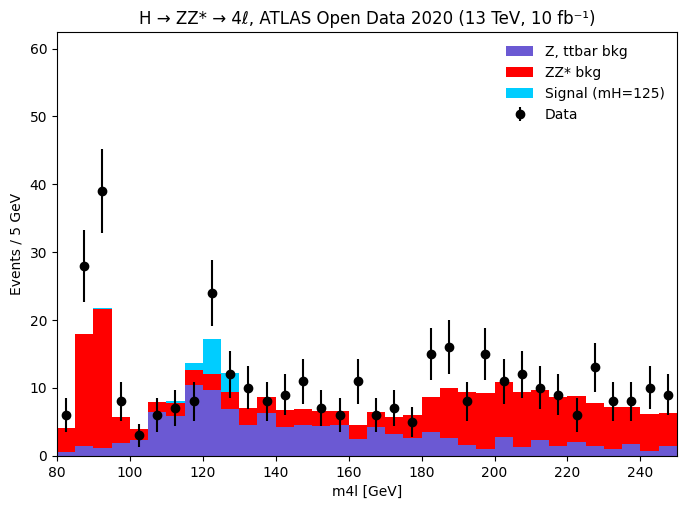

120-130 GeV window: data = 36 | background = 21.4 | signal = 8.0


In [4]:
import os
import time
import urllib.request

import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
BASE = "https://opendata.cern.ch/eos/opendata/atlas/OutreachDatasets/2020-01-22/4lep/"
LUMI = 10  # integrated luminosity in fb^-1 (data_A + data_B + data_C + data_D)

samples = {
    "data":            {"list": ["data_A", "data_B", "data_C", "data_D"]},
    "Z, ttbar bkg":    {"list": ["Zee", "Zmumu", "ttbar_lep"],        "color": "#6b59d3"},
    "ZZ* bkg":         {"list": ["llll"],                             "color": "#ff0000"},
    "Signal (mH=125)": {"list": ["ggH125_ZZ4lep", "VBFH125_ZZ4lep",
                                 "WH125_ZZ4lep", "ZH125_ZZ4lep"],     "color": "#00cdff"},
}

BASE_BRANCHES = ["lep_pt", "lep_eta", "lep_phi", "lep_E", "lep_charge", "lep_type"]
MC_BRANCHES = ["mcWeight", "scaleFactor_PILEUP", "scaleFactor_ELE",
               "scaleFactor_MUON", "scaleFactor_LepTRIGGER"]

# ---------------------------------------------------------------
# Download helper: caches files locally and retries on failure
# ---------------------------------------------------------------
os.makedirs("data_cache", exist_ok=True)

def fetch(url, tries=4):
    """Download a file once into data_cache/ and return the local path."""
    local = os.path.join("data_cache", url.split("/")[-1])
    if os.path.exists(local) and os.path.getsize(local) > 0:
        return local  # already downloaded
    for i in range(tries):
        try:
            urllib.request.urlretrieve(url, local + ".part")
            os.replace(local + ".part", local)
            return local
        except Exception as e:
            print(f"    attempt {i + 1} failed: {e}")
            time.sleep(3 * (i + 1))  # wait a bit longer after each failure
    raise RuntimeError(f"Could not download: {url}")

# ---------------------------------------------------------------
# Load one sample, apply the event selection, compute m4l and weights
# ---------------------------------------------------------------
def load(name, is_data):
    if is_data:
        url = f"{BASE}Data/{name}.4lep.root"
    else:
        dsid = infofile.infos[name]["DSID"]
        url = f"{BASE}MC/mc_{dsid}.{name}.4lep.root"

    with uproot.open(fetch(url) + ":mini") as tree:
        ev = tree.arrays(BASE_BRANCHES + ([] if is_data else MC_BRANCHES))
    n_in = len(ev)

    # ATLAS selection: use the first four leptons, require total charge = 0
    # and lepton types eeee, mumumumu or eemumu (type sum = 44, 48 or 52)
    charge_sum = ak.sum(ev.lep_charge[:, :4], axis=1)
    type_sum = ak.sum(ev.lep_type[:, :4], axis=1)
    ev = ev[(charge_sum == 0) & ((type_sum == 44) | (type_sum == 48) | (type_sum == 52))]

    # Build four-vectors and compute the 4-lepton invariant mass (MeV -> GeV)
    p4 = ak.zip({"pt": ev.lep_pt[:, :4], "eta": ev.lep_eta[:, :4],
                 "phi": ev.lep_phi[:, :4], "E": ev.lep_E[:, :4]},
                with_name="Momentum4D")
    m4l = ak.to_numpy(ak.sum(p4, axis=1).mass) / 1000

    # Event weights: 1 for data, cross-section x scale factors for simulation
    if is_data:
        w = np.ones(len(ev))
    else:
        info = infofile.infos[name]
        xsec_weight = LUMI * 1000 * info["xsec"] / (info["sumw"] * info["red_eff"])
        w = ak.to_numpy(xsec_weight * ev.mcWeight * ev.scaleFactor_PILEUP *
                        ev.scaleFactor_ELE * ev.scaleFactor_MUON *
                        ev.scaleFactor_LepTRIGGER)

    print(f"  {name}: nIn={n_in}, nOut={len(ev)}")
    return m4l, w

# ---------------------------------------------------------------
# Process all samples
# ---------------------------------------------------------------
results = {}
for group, cfg in samples.items():
    print(group)
    parts = [load(n, group == "data") for n in cfg["list"]]
    results[group] = (np.concatenate([p[0] for p in parts]),
                      np.concatenate([p[1] for p in parts]))

print("Data events after selection:", len(results["data"][0]), "(official ATLAS notebook: 507)")

# ---------------------------------------------------------------
# Plot: data points on top of the stacked simulation
# ---------------------------------------------------------------
edges = np.arange(80, 255, 5)
centres = edges[:-1] + 2.5
data_counts, _ = np.histogram(results["data"][0], bins=edges)

bkg_groups = ["Z, ttbar bkg", "ZZ* bkg"]
sig_group = "Signal (mH=125)"

fig, ax = plt.subplots(figsize=(8, 5.5))

# Stacked backgrounds
ax.hist([results[k][0] for k in bkg_groups], bins=edges,
        weights=[results[k][1] for k in bkg_groups], stacked=True,
        color=[samples[k]["color"] for k in bkg_groups], label=bkg_groups)

# Signal stacked on top of the total background
bkg_total = sum(np.histogram(results[k][0], bins=edges, weights=results[k][1])[0]
                for k in bkg_groups)
ax.hist(results[sig_group][0], bins=edges, weights=results[sig_group][1],
        bottom=bkg_total, color=samples[sig_group]["color"], label=sig_group)

# Data with statistical (Poisson) errors
ax.errorbar(centres, data_counts, yerr=np.sqrt(data_counts), fmt="ko", label="Data")

ax.set_xlim(80, 250)
ax.set_ylim(0, data_counts.max() * 1.6)
ax.set_xlabel("m4l [GeV]")
ax.set_ylabel("Events / 5 GeV")
ax.set_title("H → ZZ* → 4ℓ, ATLAS Open Data 2020 (13 TeV, 10 fb⁻¹)")
ax.legend(frameon=False)
plt.savefig("m4l_data_vs_mc.png", dpi=150)
plt.show()

# ---------------------------------------------------------------
# Event yields in the 120-130 GeV window
# ---------------------------------------------------------------
def window_yield(group, lo=120, hi=130):
    m, w = results[group]
    mask = (m >= lo) & (m < hi)
    return w[mask].sum()

print("120-130 GeV window: data =", int(window_yield("data")),
      "| background =", round(sum(window_yield(k) for k in bkg_groups), 1),
      "| signal =", round(window_yield(sig_group), 1))